<a href="https://colab.research.google.com/github/azrapatvi/Ml_practice/blob/main/18_nyc_roomtype_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importing libraries

In [193]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [194]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


In [195]:
path

'/kaggle/input/new-york-city-airbnb-open-data'

In [196]:
import os

df=pd.read_csv(os.path.join(path,'AB_NYC_2019.csv'))

In [197]:
df.head(2)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355


In [198]:
df.shape

(48895, 16)

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [200]:
df.head(2)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355


the only column whose data type i need to change is last_review becuase it contains dates but the type of this column is object

In [201]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [202]:
df.describe(include='all') # with include all we can gett all the columns from the dataset

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [203]:
missing=df.isnull().sum().reset_index()

missing[missing[0]>0]

,index,0
1,name,16
3,host_name,21
12,last_review,10052
13,reviews_per_month,10052


In [204]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64



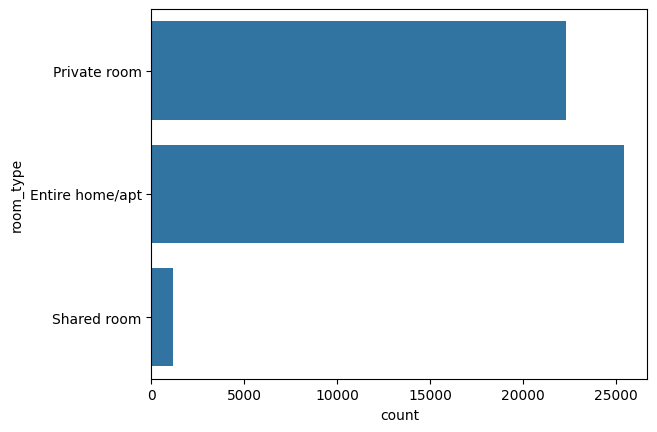

In [205]:
print(df['room_type'].value_counts())
print()

sns.countplot(df['room_type'])
plt.show()

the data is imabalanced, so as our target column is imbalanced there are some chances that our model will become little biased

In [206]:
num_cols=[i for i in df.columns if df[i].dtypes!='O']
num_cols

['id',
 'host_id',
 'latitude',
 'longitude',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

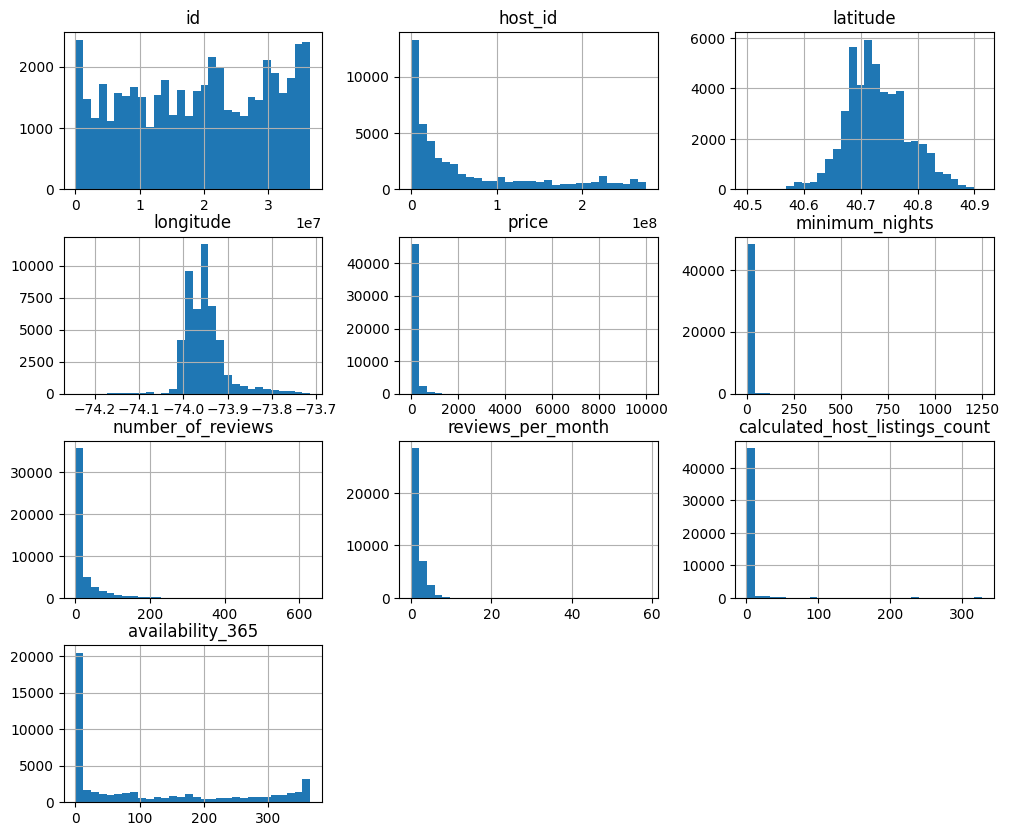

In [207]:
df[num_cols].hist(bins=30,figsize=(12,10))
plt.show()

In [208]:
cat_cols=[i for i in df.columns if df[i].dtypes=='O']
cat_cols

['name',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'room_type',
 'last_review']

In [209]:
cat_cols.remove('name')
cat_cols.remove('host_name')

In [210]:
cat_cols

['neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']

In [211]:
for i in cat_cols:
  print(df[i].unique())

['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']
['Kensington' 'Midtown' 'Harlem' 'Clinton Hill' 'East Harlem'
 'Murray Hill' 'Bedford-Stuyvesant' "Hell's Kitchen" 'Upper West Side'
 'Chinatown' 'South Slope' 'West Village' 'Williamsburg' 'Fort Greene'
 'Chelsea' 'Crown Heights' 'Park Slope' 'Windsor Terrace' 'Inwood'
 'East Village' 'Greenpoint' 'Bushwick' 'Flatbush' 'Lower East Side'
 'Prospect-Lefferts Gardens' 'Long Island City' 'Kips Bay' 'SoHo'
 'Upper East Side' 'Prospect Heights' 'Washington Heights' 'Woodside'
 'Brooklyn Heights' 'Carroll Gardens' 'Gowanus' 'Flatlands' 'Cobble Hill'
 'Flushing' 'Boerum Hill' 'Sunnyside' 'DUMBO' 'St. George' 'Highbridge'
 'Financial District' 'Ridgewood' 'Morningside Heights' 'Jamaica'
 'Middle Village' 'NoHo' 'Ditmars Steinway' 'Flatiron District'
 'Roosevelt Island' 'Greenwich Village' 'Little Italy' 'East Flatbush'
 'Tompkinsville' 'Astoria' 'Clason Point' 'Eastchester' 'Kingsbridge'
 'Two Bridges' 'Queens Village' 'Rockaway Beach' 

In [212]:
cat_cols.remove('last_review')

In [213]:
cat_cols.remove('neighbourhood')

cat_cols

['neighbourhood_group', 'room_type']

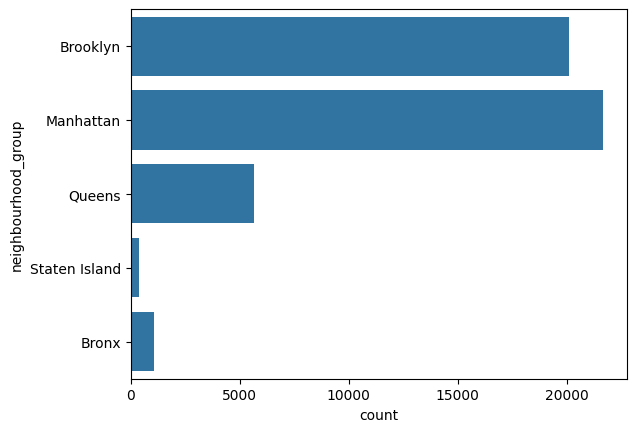

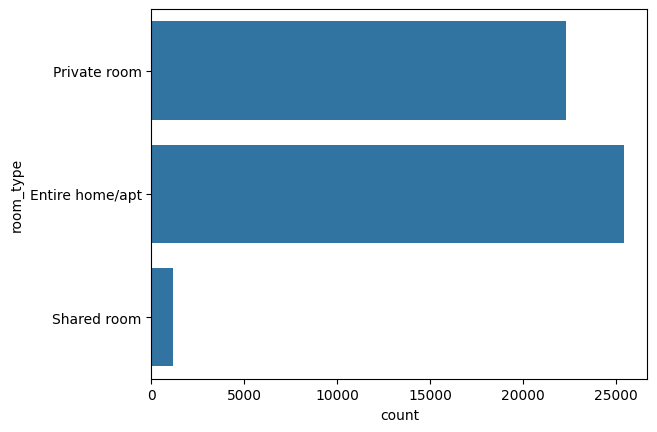

In [214]:
for i in cat_cols:
  sns.countplot(df[i])
  plt.show()

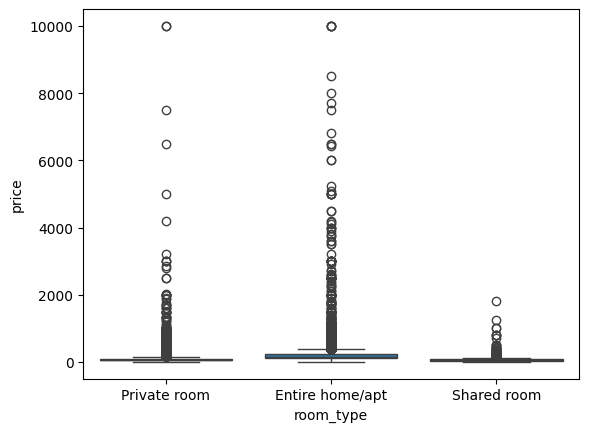

In [215]:
sns.boxplot(data=df,x='room_type',y='price')
plt.show()

In [216]:
num_cols

['id',
 'host_id',
 'latitude',
 'longitude',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [217]:
num_cols.remove('id')
num_cols.remove('host_id')

In [218]:
num_cols

['latitude',
 'longitude',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [219]:
df[num_cols].corr()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
latitude,1.000000,0.084788,0.033939,0.024869,-0.015389,-0.010142,0.019517,-0.010983
longitude,0.084788,1.000000,-0.150019,-0.062747,0.059094,0.145948,-0.114713,0.082731
price,0.033939,-0.150019,1.000000,0.042799,-0.047954,-0.030608,0.057472,0.081829
minimum_nights,0.024869,-0.062747,0.042799,1.000000,-0.080116,-0.121702,0.127960,0.144303
number_of_reviews,-0.015389,0.059094,-0.047954,-0.080116,1.000000,0.549868,-0.072376,0.172028
reviews_per_month,-0.010142,0.145948,-0.030608,-0.121702,0.549868,1.000000,-0.009421,0.185791
calculated_host_listings_count,0.019517,-0.114713,0.057472,0.127960,-0.072376,-0.009421,1.000000,0.225701
availability_365,-0.010983,0.082731,0.081829,0.144303,0.172028,0.185791,0.225701,1.000000


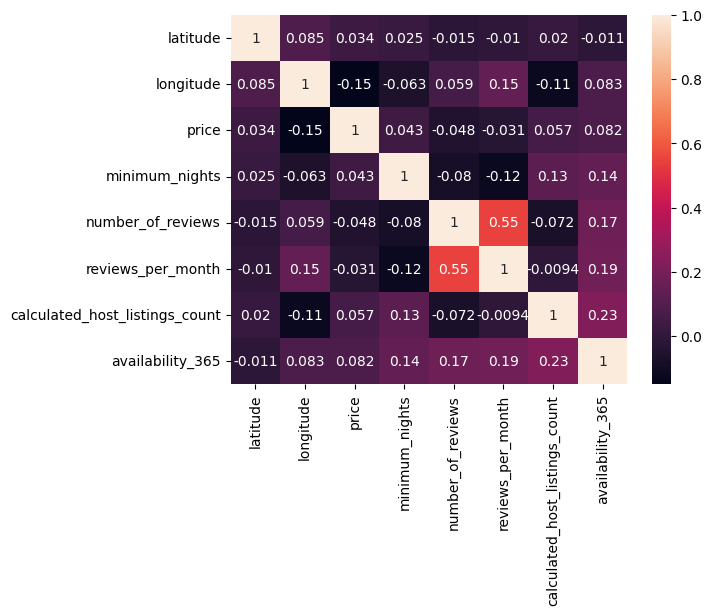

In [220]:
sns.heatmap(df[num_cols].corr(),annot=True)
plt.show()

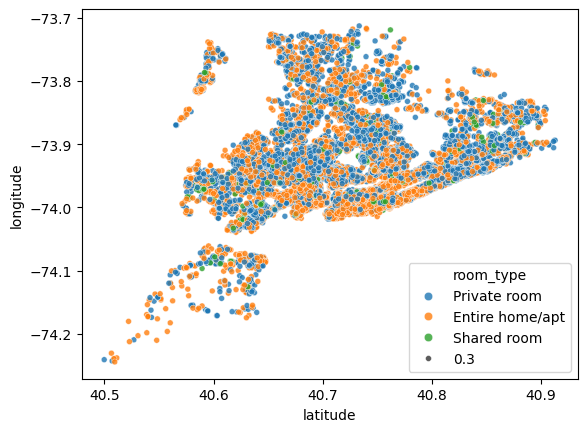

In [221]:
sns.scatterplot(x='latitude',y='longitude',data=df,hue='room_type',alpha=0.8,size=0.3)
plt.show()

so we can see that in above the points more are of private room and entire home...

In [222]:
df_clean=df.drop(['id','name','host_id','host_name','last_review'],axis=1)

df_clean

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,6,2


In [223]:
missing[missing[0]>0]

,index,0
1,name,16
3,host_name,21
12,last_review,10052
13,reviews_per_month,10052


In [224]:
missing_cols=['name','host_name','last_review','reviews_per_month']

In [225]:
for i in df_clean.columns:
  if i in missing_cols:
    print(i)

reviews_per_month


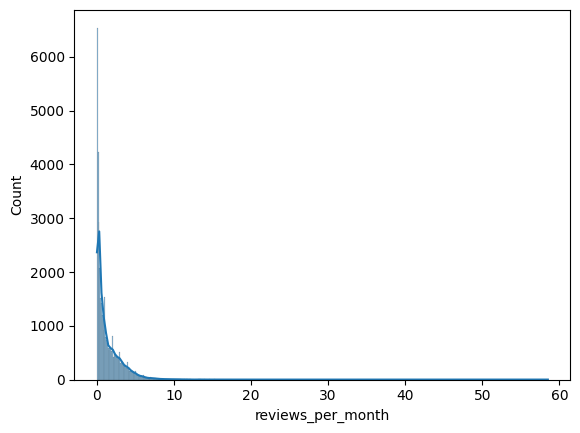

In [226]:
sns.histplot(df['reviews_per_month'],kde=True)
plt.show()

In [227]:
df_clean

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,6,2


In [228]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 4.1+ MB


In [229]:
# when review is missing means review didnt come so will fill it with 0

df_clean['reviews_per_month']=df_clean['reviews_per_month'].fillna(0)

In [230]:
# so there is alot of outliers in our data
# so we can just remove entire rows instead we will clip themm
# means instead of deletign we can replace the extreme values with boundary values

price_cap=df_clean['price'].quantile(0.99)
nights_cap=df_clean['minimum_nights'].quantile(0.99)

df_clean['price']=df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights']=df_clean['minimum_nights'].clip(upper=nights_cap)

In [231]:
print(df_clean['price'].max())
print(price_cap)

799
799.0


What clipping does: Instead of deleting those rows, you just "cap" the value.


Example: if you say "clip at 800"

Price = 150 → stays 150
Price = 5000 → becomes 800
Price = 10000 → becomes 800

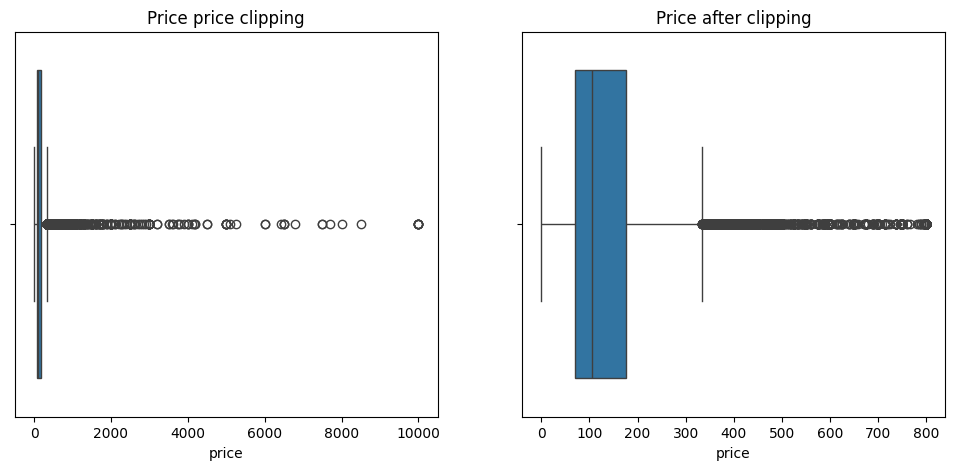

In [232]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['price'])
plt.title("Price price clipping")


plt.subplot(1,2,2)
sns.boxplot(x=df_clean['price'])
plt.title("Price after clipping")

plt.show()

In [233]:
print(df_clean['minimum_nights'].max())
print(nights_cap)

45
45.0


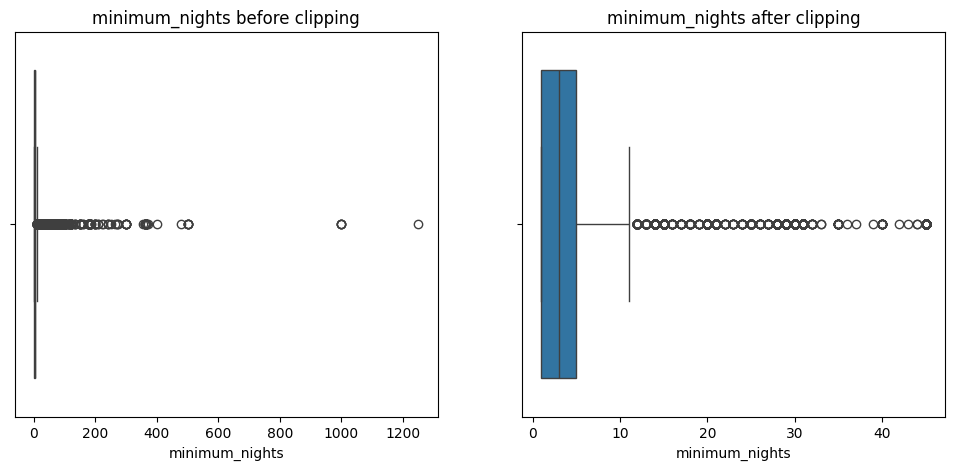

In [234]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x=df['minimum_nights'])
plt.title("minimum_nights before clipping")


plt.subplot(1,2,2)
sns.boxplot(x=df_clean['minimum_nights'])
plt.title("minimum_nights after clipping")

plt.show()

Split the dataset

In [235]:
X=df_clean.drop('room_type',axis=1)
y=df_clean['room_type']

In [236]:
X

,neighbourhood_group,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,70,2,0,0.00,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,40,4,0,0.00,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,115,10,0,0.00,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,55,1,0,0.00,6,2


In [237]:
y


,room_type
0,Private room
1,Entire home/apt
2,Private room
3,Entire home/apt
4,Entire home/apt
...,...
48890,Private room
48891,Private room
48892,Entire home/apt
48893,Shared room


In [238]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#tratify =y is to make sure that in bothh the splits means in training as well as in testing
# thee ratios gets mentained

# means the room type column has 3 classes but one type of class is very low
# menas the classes areimbalanced

# so if we dont do the stratify=y so in the training what will happend only few caes on few classes
# will be there and this will mak ethe model bias

# lets say we are doing fraud detection and our data has 900 not fraud and 100 fraud
# if we dont do the stratify=y sooin trainign what will happeend 900 nf and 2-3 fraud casess will go
# and remaining will kept for testing
# so with the mode becomes biased toward with non fraud

# thats why we have stratify=y that will doo splitt same in trainign as well as testing
# so in training you will be having 90% nf and 10%f and in testing aagain same 90% trinaign and 10%testing

In [239]:
num_cols

['latitude',
 'longitude',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [240]:
cat_cols=[i for i in X.columns if X[i].dtypes=='O']
cat_cols

['neighbourhood_group', 'neighbourhood']

In [241]:
df_clean[num_cols].skew() # to check the skewnes os as we have skewed data will apply some transformer to deal witht the skewness
# power tranformer and log transformer is also there

# use power transformer when the data skewness dont have any negatively skewed data , all are positive values


,0
latitude,0.237167
longitude,1.284210
price,2.776321
minimum_nights,2.360347
number_of_reviews,3.690635
reviews_per_month,3.300723
calculated_host_listings_count,7.933174
availability_365,0.763408


In [242]:
# will create dfferent pipeline for numericalcolumns and categorical column
# ("skew",PowerTransformer(method="yeo-johnson")), # for dealing with skeweness we remove this one becausee we addedd amny 0 valuess that can making it this overflow


from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,PowerTransformer
from sklearn.compose import ColumnTransformer

# pipeline for tranforming numerical cols
num_pipeline=Pipeline(
    [
        ("impute",SimpleImputer(strategy='median')), # means fill the missing value with median

        ("standard_scaler",StandardScaler()) # will do scaling on all numeric features
    ]
)

# pipeline for tranforming categorical cols
cat_pipeline=Pipeline(
    [
        ("impute",SimpleImputer(strategy='most_frequent')),# means in categorical columns fill the missing value with mode
        ("ohe",OneHotEncoder(handle_unknown='ignore'))
    ]
)


preprocessor=ColumnTransformer(
    [
        ("num_cols",num_pipeline,num_cols), # and num_piepline will be applied on numerical cols
        ("cat_cols",cat_pipeline,cat_cols) # so the cateogrical pipeline will applied on cat cols
    ]
)

preprocessor


ColumnTransformer(transformers=[('num_cols',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('standard_scaler',
                                                  StandardScaler())]),
                                 ['latitude', 'longitude', 'price',
                                  'minimum_nights', 'number_of_reviews',
                                  'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('cat_cols',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

In [243]:
import warnings
warnings.filterwarnings('ignore')

In [245]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier() # it dont support class_weight='balanced'
}

In [246]:
from sklearn.model_selection import cross_val_score

for name,model in models.items():
  print(name)
  pipe=Pipeline(
      [
  ("preprocessor",preprocessor),
  ("model",model)
      ]
  )

  accuracy = cross_val_score(pipe, X_train, y_train, cv=3, scoring="accuracy")
  macrof1 = cross_val_score(pipe, X_train, y_train, cv=3, scoring="f1_macro")

  print(f"{name} -> Accuracy: {accuracy.mean():.3f} , F1: {macrof1.mean():.3f}")


Logistic Regression
Logistic Regression -> Accuracy: 0.663 , F1: 0.526
Decision Tree
Decision Tree -> Accuracy: 0.783 , F1: 0.650
Random Forest
Random Forest -> Accuracy: 0.852 , F1: 0.717
Gradient Boosting
Gradient Boosting -> Accuracy: 0.850 , F1: 0.708


In [247]:
best_pipeline=Pipeline(
    [
        ("preprocessor",preprocessor),
        ("model",RandomForestClassifier(class_weight='balanced'))
    ]
)

best_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'price', 'minimum_nights',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'calculated_host_listings_count',
                                                   'availability_365']),
                                                 ('cat_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['neighbourhood_group',
                                                   'neighbourhood'])])),
                ('model', RandomForestClassifier(class_weight='balanced'))])

In [254]:
# so we are selecting random forest becuase the accuracy and all is obviously high
# we can also select gradient boosting but becuase our data is imabalnced and we haventdeal with it
# in gradient boosting using class_weight='balanced' thats why we are not selecting it ...that might be biased model
# also graident boosting didnt support the class_weight='imbalnced ..

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators': [10, 50, 100, 150],
    'model__max_depth': [5, 10, 15, 50],
    'model__min_samples_split': [2, 5, None]
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

{'model__n_estimators': 50, 'model__min_samples_split': 5, 'model__max_depth': 50}
0.7284139866420428


In [255]:
search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'price', 'minimum_nights',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'calculated_host_listings_count',
                                                   'availability_365']),
                                                 ('cat_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['neighbourhood_group',
                                                   'neighbourhood'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=50,
                                        min_samples_split=5,
                                        n_estimators=50))])

In [256]:
best_pipeline=search.best_estimator_

In [257]:
best_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'price', 'minimum_nights',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'calculated_host_listings_count',
                                                   'availability_365']),
                                                 ('cat_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['neighbourhood_group',
                                                   'neighbourhood'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=50,
                                        min_samples_split=5,
                                        n_estimators=50))])

In [258]:
y_pred=best_pipeline.predict(X_test)

In [259]:
y_pred

array(['Private room', 'Private room', 'Entire home/apt', ...,
       'Entire home/apt', 'Entire home/apt', 'Private room'], dtype=object)

In [260]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8582677165354331

Classification Report:
                 precision    recall  f1-score   support

Entire home/apt       0.88      0.88      0.88      5082
   Private room       0.84      0.86      0.85      4465
    Shared room       0.90      0.34      0.50       232

       accuracy                           0.86      9779
      macro avg       0.87      0.70      0.74      9779
   weighted avg       0.86      0.86      0.86      9779



In [263]:
import joblib

joblib.dump(best_pipeline,"best_pipeline.pkl")

['best_pipeline.pkl']

In [244]:
df_clean.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
